# Colab notebook: $k!$ multiset scaling and timing for $\mathrm{tr}(H^k)$

Set

```julia
ENV["PAULISTRINGS_REPO_URL"] = "https://github.com/<your-user>/PauliStrings.jl.git"
ENV["PAULISTRINGS_REPO_REF"] = "<branch-name-or-commit-sha>"
```

The goal is to show that grouping ordered products in $\mathrm{tr}(H^k)$ into multisets, pruning by the Pauli identity condition, and measuring which parts of the new algorithm are responsible for speedup. The speedup is particularly significant for odd $k$.


## 1. Activate a checkout to PauliStrings.ji.git



In [1]:
import Pkg

repo_url_was_set = haskey(ENV, "PAULISTRINGS_REPO_URL")
repo_ref_was_set = haskey(ENV, "PAULISTRINGS_REPO_REF")
ENV["PAULISTRINGS_REPO_URL"] = get(ENV, "PAULISTRINGS_REPO_URL", "https://github.com/nicolasloizeau/PauliStrings.jl.git")
ENV["PAULISTRINGS_REPO_REF"] = get(ENV, "PAULISTRINGS_REPO_REF", "main")
ENV["PAULISTRINGS_SKIP_GIT_PULL"] = get(ENV, "PAULISTRINGS_SKIP_GIT_PULL", "false")

function find_local_repo()
    candidate_dirs = unique(filter(d -> !isempty(d), [
        get(ENV, "PAULISTRINGS_REPO_DIR", ""),
        pwd(),
        joinpath(pwd(), "PauliStrings.jl"),
        "/content/PauliStrings.jl",
    ]))

    for dir in candidate_dirs
        if isfile(joinpath(dir, "Project.toml")) && isdir(joinpath(dir, "src"))
            return abspath(dir)
        end
    end
    return nothing
end

function git_refresh!(repo_dir; checkout_configured_ref=false)
    get(ENV, "PAULISTRINGS_SKIP_GIT_PULL", "false") == "true" && return repo_dir
    repo_url = ENV["PAULISTRINGS_REPO_URL"]
    repo_ref = ENV["PAULISTRINGS_REPO_REF"]
    cd(repo_dir) do
        isdir(".git") || return
        if checkout_configured_ref
            run(`git remote set-url origin $repo_url`)
            run(`git fetch origin $repo_ref`)
            try
                run(`git checkout $repo_ref`)
            catch
                run(`git checkout --detach FETCH_HEAD`)
            end
            try
                run(`git pull --ff-only origin $repo_ref`)
            catch err
                @warn "Skipping git pull; this is expected for detached commits or non-branch refs" exception=(err, catch_backtrace())
            end
        else
            try
                run(`git pull --ff-only`)
            catch err
                @warn "Skipping git pull for existing checkout; set PAULISTRINGS_REPO_URL/REF to force a specific ref" exception=(err, catch_backtrace())
            end
        end
        run(`git log -1 --oneline`)
    end
    return repo_dir
end

repo_dir = find_local_repo()
force_ref = repo_url_was_set || repo_ref_was_set
if repo_dir === nothing
    repo_url = ENV["PAULISTRINGS_REPO_URL"]
    clone_dir = abspath("PauliStrings.jl")
    run(`git clone $repo_url $clone_dir`)
    repo_dir = clone_dir
    git_refresh!(repo_dir; checkout_configured_ref=true)
else
    git_refresh!(repo_dir; checkout_configured_ref=force_ref)
end

Pkg.activate(repo_dir)
Pkg.instantiate()
Pkg.precompile()
Pkg.status()
println("Using PauliStrings.jl checkout at: ", repo_dir)


Cloning into '/content/PauliStrings.jl'...


Your branch is up to date with 'origin/main'.


From https://github.com/nicolasloizeau/PauliStrings.jl
 * branch            main       -> FETCH_HEAD
Already on 'main'


Already up to date.
4d48ac3 feat: import OpenQASM circuits into Circuit (#110)


From https://github.com/nicolasloizeau/PauliStrings.jl
 * branch            main       -> FETCH_HEAD
  Activating project at `/content/PauliStrings.jl`
    Updating registry at `~/.julia/registries/General.toml`
   Installed Indexing ──────── v1.1.1
   Installed BitIntegers ───── v0.3.7
   Installed ProgressBars ──── v1.5.1
   Installed Combinatorics ─── v1.1.0
   Installed Dictionaries ──── v0.4.6
   Installed VectorInterface ─ v0.6.0
    Updating `/content/PauliStrings.jl/Project.toml`
  [c3b6d118] + BitIntegers v0.3.7
  [861a8166] + Combinatorics v1.1.0
  [85a47980] + Dictionaries v0.4.6
  [49802e3a] + ProgressBars v1.5.1
  [409d34a3] + VectorInterface v0.6.0
  [37e2e46d] ~ LinearAlgebra ⇒ v1.12.0
  [9a3f8284] ~ Random ⇒ v1.11.0
  [2f01184e] ~ SparseArrays ⇒ v1.12.0
    Updating `/content/PauliStrings.jl/Manifest.toml`
  [c3b6d118] + BitIntegers v0.3.7
  [861a8166] + Combinatorics v1.1.0
  [85a47980] + Dictionaries v0.4.6
  [313cdc1a] + Indexing v1.1.1
  [49802e3a] + ProgressBars v1

Project PauliStrings v1.10.1
Status `/content/PauliStrings.jl/Project.toml`
  [c3b6d118] BitIntegers v0.3.7
  [861a8166] Combinatorics v1.1.0
  [85a47980] Dictionaries v0.4.6
  [49802e3a] ProgressBars v1.5.1
  [409d34a3] VectorInterface v0.6.0
  [37e2e46d] LinearAlgebra v1.12.0
  [9a3f8284] Random v1.11.0
  [2f01184e] SparseArrays v1.12.0
Using PauliStrings.jl checkout at: /content/PauliStrings.jl


## 2. Define the transverse-field Ising example

We use the Ising Hamiltonian

$$
H = h\sum_{i=1}^{N} X_i + \sum_{i=1}^{N} Z_i Z_{i+1},
$$

with periodic boundary conditions.  The key parameters are:

* $N$: number of qubits/sites;
* $h$: transverse field;
* $M$: number of Pauli terms in $H$;
* $k$: moment order.


In [2]:
using PauliStrings
using Printf
using Statistics

function ising(h, N)
    H = Operator(N)
    for i in 1:N
        H += h, "X", i
    end
    for i in 1:N
        H += "Z", i, "Z", mod1(i + 1, N)
    end
    return H
end

N_demo = 12
h_demo = 0.5
H_demo = ising(h_demo, N_demo)
M_demo = length(H_demo.strings)

println("N = ", N_demo)
println("h = ", h_demo)
println("M = length(H.strings) = ", M_demo)


N = 12
h = 0.5
M = length(H.strings) = 24


## 3. Count ordered tuples versus identity-yielding multisets

This section is a combinatorial sanity check.  It counts:

$$
\texttt{all ordered} = M^k,
$$

$$
\texttt{all multisets} = \binom{M+k-1}{k},
$$

and the identity-yielding subset.

The ratio

$$
\frac{M^k}{\binom{M+k-1}{k}} \approx k!
$$

is the high-level grouping factor.  The identity-yielding ratio shows the same idea after applying the trace condition.


In [3]:
function addcount!(d, key, value)
    d[key] = get(d, key, big(0)) + value
    return d
end

function ordered_identity_count(strings, k)
    T = typeof(strings[1].v)
    zero_key = (zero(T), zero(T))
    dp = Dict{Tuple{T,T},BigInt}(zero_key => big(1))

    for _ in 1:k
        next = Dict{Tuple{T,T},BigInt}()
        for ((v, w), c) in dp
            for p in strings
                addcount!(next, (v ⊻ p.v, w ⊻ p.w), c)
            end
        end
        dp = next
    end

    return get(dp, zero_key, big(0))
end

function identity_multiset_counts(strings, k)
    M = length(strings)
    T = typeof(strings[1].v)
    zero_v = zero(T)
    zero_w = zero(T)
    counts = zeros(Int, M)
    factorials = [factorial(big(i)) for i in 0:k]
    identity_multisets = Ref(big(0))
    ordered_permutations_represented = Ref(big(0))

    function visit(i, remaining, v, w)
        if i > M
            if remaining == 0 && v == zero_v && w == zero_w
                identity_multisets[] += 1
                denom = big(1)
                for c in counts
                    denom *= factorials[c + 1]
                end
                ordered_permutations_represented[] += factorials[k + 1] ÷ denom
            end
            return nothing
        end

        p = strings[i]
        pv = zero_v
        pw = zero_w
        for c in 0:remaining
            counts[i] = c
            visit(i + 1, remaining - c, v ⊻ pv, w ⊻ pw)
            pv ⊻= p.v
            pw ⊻= p.w
        end
        counts[i] = 0
        return nothing
    end

    visit(1, k, zero_v, zero_w)
    return identity_multisets[], ordered_permutations_represented[]
end

function scaling_rows(H; kmax=10)
    strings = H.strings
    M = length(strings)
    rows = NamedTuple[]

    for k in 1:kmax
        all_ordered = big(M)^k
        all_multisets = binomial(big(M + k - 1), k)
        identity_ordered = ordered_identity_count(strings, k)
        identity_multisets, represented = identity_multiset_counts(strings, k)
        @assert represented == identity_ordered
        all_ratio = Float64(all_ordered) / Float64(all_multisets)
        identity_ratio = iszero(identity_multisets) ? NaN : Float64(identity_ordered) / Float64(identity_multisets)
        kfact = factorial(big(k))
        push!(rows, (; k, M, all_ordered, all_multisets, all_ratio,
                      identity_ordered, identity_multisets, identity_ratio, kfact))
    end

    return rows
end

scaling = scaling_rows(H_demo; kmax=10)

@printf("%3s %3s %18s %18s %14s %18s %18s %14s %18s\n",
        "k", "M", "all_ordered", "all_multisets", "all ratio", "id ordered", "id multisets", "id ratio", "k!")
for r in scaling
    @printf("%3d %3d %18s %18s %14.3f %18s %18s %14.3f %18s\n",
            r.k, r.M, string(r.all_ordered), string(r.all_multisets), r.all_ratio,
            string(r.identity_ordered), string(r.identity_multisets), r.identity_ratio, string(r.kfact))
end


  k   M        all_ordered      all_multisets      all ratio         id ordered       id multisets       id ratio                 k!
  1  24                 24                 24          1.000                  0                  0            NaN                  1
  2  24                576                300          1.920                 24                 24          1.000                  2
  3  24              13824               2600          5.317                  0                  0            NaN                  6
  4  24             331776              17550         18.905               1680                300          5.600                 24
  5  24            7962624              98280         81.020                  0                  0            NaN                120
  6  24          191102976             475020        402.305             190464               2600         73.255                720
  7  24         4586471424            2035800       2252.909         

## 4. Detailed timing instrumentation

This section mirrors the multiset implementation and separates the runtime into pieces:

* `old_time`: preserved half-power implementation `_trace_product_power_halves`;
* `public_time`: the package-level `trace_product(H,k; scale=1)` dispatch, included as a sanity check for what users actually call; it can match `old_time` when the production code falls back to `_trace_product_power_halves`;
* `parity_time`: finding identity-yielding odd supports $S$;
* `precompute_time`: building coefficient powers $c_i^m$;
* `pair_enum_time`: distributing remaining pairs $q=(k-|S|)/2$ across all strings;
* `phase_time`: computing $\Phi(\mathbf{n})$ for each surviving multiset;
* `new_total_time`: total instrumented multiset time;
* `fallback`: whether the instrumented multiset path hit the safety cap and returned to the preserved half-power method;
* `speedup = old_time / new_total_time` for non-fallback rows only.

This makes it clear which algorithmic piece is responsible for each part of the observed speedup.  The speedup ratio intentionally uses `old_time`, not `public_time`, because `public_time` may already include the new multiset method or the fallback depending on the row.

To avoid depending on unexported package internals, this notebook defines local instrumentation copies of the parity-pattern and phase-sum helpers (see above).

A speedup below $1$ means the multiset overhead dominates for that small benchmark point.  A `NaN` speedup is also intentional: it means the instrumented multiset search hit the safety cap `NOTEBOOK_MULTISET_MAX_REACHABLE` before finishing, so there is no completed multiset runtime to divide by.  In that case the production `trace_product` implementation should use the safe half-power fallback instead of forcing an oversized multiset enumeration.  The main timing table compares `k_values = vcat(collect(3:10), collect(11:2:15))`, so the larger odd values beyond $11$ are included in the same speedup calculation, and in fact, these relatively large odd cases are where the speedup grows larger 1 .  The notebook cap is configurable through `ENV["NOTEBOOK_MULTISET_MAX_REACHABLE"]` before this cell.  The multiset path is expected to help only once the old half-power path starts building sufficiently large intermediate operators, but before the multiset count exceeds the cap.  The timing code warms up each path before recording samples to reduce compilation noise.


In [4]:
NOTEBOOK_MULTISET_MAX_REACHABLE = parse(Int, get(ENV, "NOTEBOOK_MULTISET_MAX_REACHABLE", "2000000000"))
println("NOTEBOOK_MULTISET_MAX_REACHABLE = ", NOTEBOOK_MULTISET_MAX_REACHABLE)

notebook_prod_phase_sign(v1::Unsigned, w2::Unsigned) = 1 - ((count_ones(v1 & w2) & 1) << 1)

function notebook_identity_parity_patterns(strings::Vector{P}, k::Int; maxstates::Int=NOTEBOOK_MULTISET_MAX_REACHABLE) where {P<:PauliString}
    M = length(strings)
    id = one(P)
    maxodd = min(k, M)
    reachable = [Set{P}() for _ in 1:(M + 1), _ in 1:(maxodd + 1)]
    push!(reachable[M + 1, 1], id)
    totalstates = 1

    for i in M:-1:1
        p = strings[i]
        for r in 0:maxodd
            dst = reachable[i, r + 1]
            union!(dst, reachable[i + 1, r + 1])
            if r > 0
                for q in reachable[i + 1, r]
                    push!(dst, p ⊻ q)
                end
            end
            totalstates += length(dst)
            totalstates > maxstates && return nothing
        end
    end

    patterns = Vector{Vector{Int}}()
    current = Int[]

    function visit(i::Int, r::Int, target::P)
        if r == 0
            target == id && push!(patterns, copy(current))
            return nothing
        end
        i > M && return nothing
        r > M - i + 1 && return nothing

        if target in reachable[i + 1, r + 1]
            visit(i + 1, r, target)
        end

        nexttarget = target ⊻ strings[i]
        if nexttarget in reachable[i + 1, r]
            push!(current, i)
            visit(i + 1, r - 1, nexttarget)
            pop!(current)
        end
        return nothing
    end

    for r in (k & 1):2:maxodd
        visit(1, r, id)
        length(patterns) > maxstates && return nothing
    end

    return patterns
end

function notebook_multiset_phase_sum(strings::Vector{P}, indices::Vector{Int}, counts0::Vector{Int}) where {P<:PauliString}
    isempty(indices) && return 1
    counts = copy(counts0)
    memo = Dict{Tuple{Vararg{Int}},Int}()

    function visit(current_v::Unsigned)
        key = Tuple(counts)
        cached = get(memo, key, nothing)
        isnothing(cached) || return cached

        total = 0
        anyleft = false
        for a in eachindex(indices)
            counts[a] == 0 && continue
            anyleft = true
            p = strings[indices[a]]
            counts[a] -= 1
            total += notebook_prod_phase_sign(current_v, p.w) * visit(current_v ⊻ p.v)
            counts[a] += 1
        end
        anyleft || (total = 1)
        memo[key] = total
        return total
    end

    return visit(zero(typeof(strings[1].v)))
end

function timed_multiset_trace(A::Operator{P,T}, k::Int; scale=1, maxstates::Int=NOTEBOOK_MULTISET_MAX_REACHABLE) where {P<:PauliString,T}
    strings = A.strings
    coeffs = A.coeffs
    M = length(strings)
    trscale = iszero(scale) ? 2.0^qubitlength(A) : scale

    parity_time = @elapsed parity_patterns = notebook_identity_parity_patterns(strings, k; maxstates=maxstates)
    isnothing(parity_patterns) && return (; fallback=true, value=nothing, pattern_count=0, multiset_count=0,
        parity_time, precompute_time=0.0, pair_enum_time=0.0, phase_time=0.0, new_total_time=parity_time)

    precompute_time = @elapsed coeffpowers = [[coeffs[i]^m for m in 0:k] for i in 1:M]

    odd = falses(M)
    indices = Int[]
    counts = Int[]
    moment = Ref(zero(T))
    multiset_count = Ref(0)
    aborted = Ref(false)
    phase_ns = Ref(0)

    function visit_counts(i::Int, remaining_pairs::Int, coeffprod)
        aborted[] && return nothing
        if i > M
            remaining_pairs == 0 || return nothing
            multiset_count[] += 1
            if multiset_count[] > maxstates
                aborted[] = true
                return nothing
            end
            t0 = time_ns()
            phase_sum = notebook_multiset_phase_sum(strings, indices, counts)
            phase_ns[] += time_ns() - t0
            moment[] += coeffprod * phase_sum
            return nothing
        end

        basecount = odd[i] ? 1 : 0
        for pairs in 0:remaining_pairs
            count = basecount + 2pairs
            if count == 0
                visit_counts(i + 1, remaining_pairs - pairs, coeffprod)
            else
                push!(indices, i)
                push!(counts, count)
                visit_counts(i + 1, remaining_pairs - pairs, coeffprod * coeffpowers[i][count + 1])
                pop!(counts)
                pop!(indices)
            end
            aborted[] && return nothing
        end
        return nothing
    end

    enum_time = @elapsed begin
        for pattern in parity_patterns
            fill!(odd, false)
            for i in pattern
                odd[i] = true
            end
            pairs = (k - length(pattern)) ÷ 2
            visit_counts(1, pairs, one(T))
            aborted[] && break
        end
    end

    phase_time = phase_ns[] / 1e9
    pair_enum_time = max(enum_time - phase_time, 0.0)
    new_total_time = parity_time + precompute_time + enum_time

    aborted[] && return (; fallback=true, value=nothing, pattern_count=length(parity_patterns), multiset_count=multiset_count[],
        parity_time, precompute_time, pair_enum_time, phase_time, new_total_time)

    return (; fallback=false, value=moment[] * trscale, pattern_count=length(parity_patterns), multiset_count=multiset_count[],
        parity_time, precompute_time, pair_enum_time, phase_time, new_total_time)
end

function minimum_elapsed(f, samples)
    # Warm up once so compile time does not dominate the comparison.
    value = f()
    times = Float64[]
    for _ in 1:samples
        t = @elapsed value = f()
        push!(times, t)
    end
    return minimum(times), value
end

function minimum_instrumented_trace(H, k; scale=1, samples=1, maxstates::Int=NOTEBOOK_MULTISET_MAX_REACHABLE)
    # Warm up once, then keep the run with the smallest measured multiset time.
    best = timed_multiset_trace(H, k; scale=scale, maxstates=maxstates)
    best_time = Inf
    for _ in 1:samples
        result = timed_multiset_trace(H, k; scale=scale, maxstates=maxstates)
        if result.new_total_time < best_time
            best = result
            best_time = result.new_total_time
        end
    end
    return best
end

function reference_trace_product_power(H, k; scale=1)
    if isdefined(PauliStrings, :_trace_product_power_halves)
        return getfield(PauliStrings, :_trace_product_power_halves)(H, k; scale=scale)
    else
        return trace_product(H, k; scale=scale)
    end
end

function detailed_timing_rows(H; k_values=3:10, samples=1, maxstates::Int=NOTEBOOK_MULTISET_MAX_REACHABLE)
    rows = NamedTuple[]
    for k in k_values
        instrumented = minimum_instrumented_trace(H, k; scale=1, samples=samples, maxstates=maxstates)
        old_time, old_value = minimum_elapsed(() -> reference_trace_product_power(H, k; scale=1), samples)
        public_time, public_value = minimum_elapsed(() -> trace_product(H, k; scale=1), samples)

        if !instrumented.fallback && old_value !== nothing
            @assert abs(instrumented.value - old_value) <= 1e-8 * max(1, abs(old_value))
        end

        speedup = instrumented.fallback ? NaN : old_time / instrumented.new_total_time
        speedup_note = instrumented.fallback ? "fallback cap" : (speedup < 1 ? "overhead" : "speedup")
        push!(rows, merge((; k, old_time, public_time, speedup, speedup_note), instrumented))
    end
    return rows
end

# Compare the small orders and the requested larger odd orders in one table.
# This can be expensive for high k; rows that exceed the multiset cap are marked as fallback/NaN.
#timing_k_values = vcat(collect(3:10), collect(11:2:41))
timing_k_values = vcat(collect(3:10), collect(11:2:15))
timing = detailed_timing_rows(H_demo; k_values=timing_k_values, samples=2)

@printf("%3s %10s %10s %10s %10s %9s %13s %10s %10s %10s %8s %10s\n",
        "k", "old", "dispatch", "new", "speedup", "fallback", "note", "parity", "pairs", "phase", "patterns", "multisets")
for r in timing
    speedup_text = isnan(r.speedup) ? "NaN" : @sprintf("%.3f", r.speedup)
    @printf("%3d %10.4g %10.4g %10.4g %10s %9s %13s %10.4g %10.4g %10.4g %8d %10d\n",
            r.k, r.old_time, r.public_time, r.new_total_time, speedup_text, string(r.fallback), r.speedup_note,
            r.parity_time, r.pair_enum_time, r.phase_time, r.pattern_count, r.multiset_count)
end


NOTEBOOK_MULTISET_MAX_REACHABLE = 2000000000
  k        old   dispatch        new    speedup  fallback          note     parity      pairs      phase patterns  multisets
  3  5.174e-05  4.486e-05  0.0008906      0.058     false      overhead   0.000888    4.6e-08          0        0          0
  4   3.58e-05  3.167e-05   0.006744      0.005     false      overhead   0.003919  0.0004232   0.002396        1        300
  5  0.0003743  0.0003659    0.01432      0.026     false      overhead    0.01431      9e-08          0        0          0
  6  0.0003799  0.0003907     0.1221      0.003     false      overhead    0.04496   0.002627    0.07446        1       2600
  7   0.003202   0.003169     0.1166      0.027     false      overhead     0.1166      8e-08          0        0          0
  8    0.00478   0.005104      2.343      0.002     false      overhead     0.2672    0.02015      2.056        1      17550
  9    0.02377    0.02032     0.7153      0.033     false      overhead     0.71

## 5. Animated speedup curve, point by point

The next cell creates a self-contained SVG animation.  Each point appears from small $k$ to large $k$, so the speedup curve is constituted dot by dot.  No external plotting libraries are used.


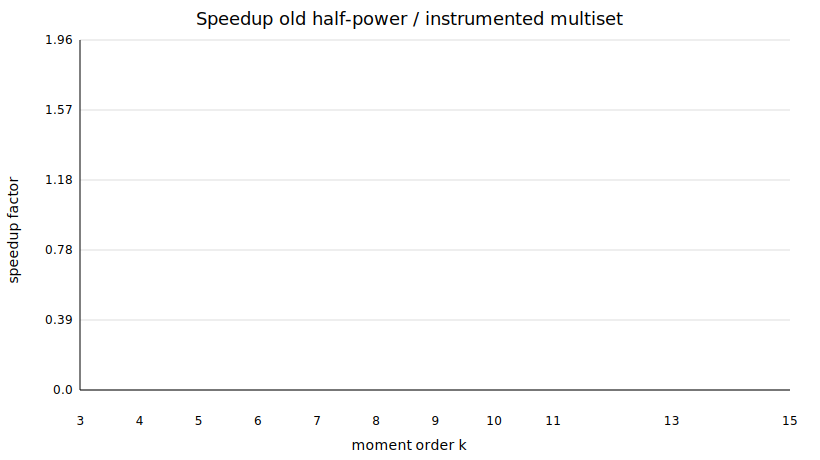

In [5]:
function animated_speedup_svg(rows; width=820, height=460)
    usable = [r for r in rows if !isnan(r.speedup) && r.speedup > 0]
    isempty(usable) && return "<svg><text x='20' y='20'>No non-fallback speedup points to plot.</text></svg>"

    left, right, top, bottom = 80.0, 30.0, 40.0, 70.0
    xs = Float64[r.k for r in usable]
    ys = Float64[r.speedup for r in usable]
    xmin, xmax = minimum(xs), maximum(xs)
    ymin, ymax = 0.0, maximum(ys) * 1.15
    xmax == xmin && (xmax += 1)
    ymax == ymin && (ymax += 1)

    xmap(x) = left + (x - xmin) / (xmax - xmin) * (width - left - right)
    ymap(y) = height - bottom - (y - ymin) / (ymax - ymin) * (height - top - bottom)

    xticks = join(["<text x='$(xmap(x))' y='$(height - 35)' text-anchor='middle' font-size='12'>$(Int(x))</text>" for x in xs])
    ytickvals = range(0, ymax; length=6)
    yticks = join(["<line x1='$left' x2='$(width-right)' y1='$(ymap(y))' y2='$(ymap(y))' stroke='#ddd'/><text x='$(left-8)' y='$(ymap(y)+4)' text-anchor='end' font-size='12'>$(round(y,digits=2))</text>" for y in ytickvals])

    circles = String[]
    labels = String[]
    lines = String[]
    for i in eachindex(usable)
        x, y = xmap(usable[i].k), ymap(usable[i].speedup)
        delay = 0.35 * (i - 1)
        push!(circles, "<circle cx='$x' cy='$y' r='5' fill='#9fc5e8' opacity='0'><animate attributeName='opacity' from='0' to='1' begin='$(delay)s' dur='0.2s' fill='freeze'/></circle>")
        push!(labels, "<text x='$(x+7)' y='$(y-7)' font-size='11' opacity='0'>$(round(usable[i].speedup,digits=2))×<animate attributeName='opacity' from='0' to='1' begin='$(delay+0.1)s' dur='0.2s' fill='freeze'/></text>")
        if i > 1
            x0, y0 = xmap(usable[i-1].k), ymap(usable[i-1].speedup)
            push!(lines, "<line x1='$x0' y1='$y0' x2='$x' y2='$y' stroke='#9fc5e8' stroke-width='2' opacity='0'><animate attributeName='opacity' from='0' to='1' begin='$(delay)s' dur='0.2s' fill='freeze'/></line>")
        end
    end

    return """
    <svg xmlns='http://www.w3.org/2000/svg' width='$width' height='$height' viewBox='0 0 $width $height'>
      <rect width='100%' height='100%' fill='white'/>
      <text x='$(width/2)' y='25' text-anchor='middle' font-size='18'>Speedup old half-power / instrumented multiset</text>
      $yticks
      <line x1='$left' x2='$(width-right)' y1='$(height-bottom)' y2='$(height-bottom)' stroke='black'/>
      <line x1='$left' x2='$left' y1='$top' y2='$(height-bottom)' stroke='black'/>
      $xticks
      <text x='$(width/2)' y='$(height-10)' text-anchor='middle' font-size='14'>moment order k</text>
      <text x='18' y='$(height/2)' transform='rotate(-90,18,$(height/2))' text-anchor='middle' font-size='14'>speedup factor</text>
      $(join(lines, "\n"))
      $(join(circles, "\n"))
      $(join(labels, "\n"))
    </svg>
    """
end

display("image/svg+xml", animated_speedup_svg(timing))


## 6. Component timing: which piece costs what?

This plot decomposes the new multiset time into:

$$
T_{\mathrm{new}}
= T_{\mathrm{parity}} + T_{\mathrm{precompute}} + T_{\mathrm{pair\ enum}} + T_{\mathrm{phase}}.
$$

It helps answer whether the bottleneck is identity support enumeration, pair distribution, or phase summation.


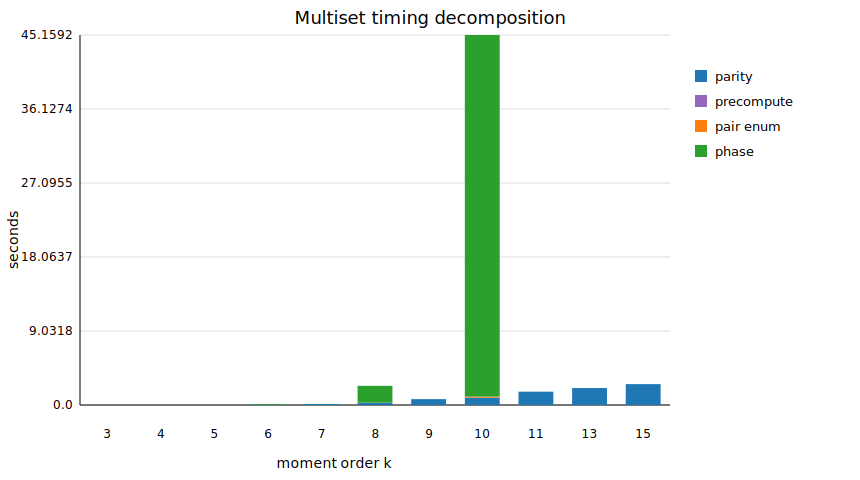

In [6]:
function component_timing_svg(rows; width=860, height=480)
    usable = [r for r in rows if !r.fallback]
    isempty(usable) && return "<svg><text x='20' y='20'>No non-fallback component timings to plot.</text></svg>"
    left, right, top, bottom = 80.0, 190.0, 35.0, 75.0
    max_total = maximum(r.new_total_time for r in usable)
    max_total == 0 && (max_total = 1.0)
    barw = (width - left - right) / length(usable) * 0.65
    gap = (width - left - right) / length(usable)
    ymap(y) = height - bottom - y / max_total * (height - top - bottom)
    colors = Dict(:parity => "#1f77b4", :precompute => "#9467bd", :pairs => "#ff7f0e", :phase => "#2ca02c")

    bars = String[]
    labels = String[]
    for (j, r) in enumerate(usable)
        x = left + (j - 0.5) * gap - barw / 2
        ybase = height - bottom
        parts = [(:parity, r.parity_time), (:precompute, r.precompute_time), (:pairs, r.pair_enum_time), (:phase, r.phase_time)]
        for (name, val) in parts
            h = val / max_total * (height - top - bottom)
            y = ybase - h
            push!(bars, "<rect x='$x' y='$y' width='$barw' height='$h' fill='$(colors[name])'/>")
            ybase = y
        end
        push!(labels, "<text x='$(x+barw/2)' y='$(height-42)' text-anchor='middle' font-size='12'>$(r.k)</text>")
    end

    legend = """
    <rect x='$(width-right+25)' y='70' width='12' height='12' fill='$(colors[:parity])'/><text x='$(width-right+45)' y='81' font-size='13'>parity</text>
    <rect x='$(width-right+25)' y='95' width='12' height='12' fill='$(colors[:precompute])'/><text x='$(width-right+45)' y='106' font-size='13'>precompute</text>
    <rect x='$(width-right+25)' y='120' width='12' height='12' fill='$(colors[:pairs])'/><text x='$(width-right+45)' y='131' font-size='13'>pair enum</text>
    <rect x='$(width-right+25)' y='145' width='12' height='12' fill='$(colors[:phase])'/><text x='$(width-right+45)' y='156' font-size='13'>phase</text>
    """

    yticks = join([begin
        y = max_total * f
        "<line x1='$left' x2='$(width-right)' y1='$(ymap(y))' y2='$(ymap(y))' stroke='#ddd'/><text x='$(left-8)' y='$(ymap(y)+4)' text-anchor='end' font-size='12'>$(round(y,digits=4))</text>"
    end for f in 0:0.2:1])

    return """
    <svg xmlns='http://www.w3.org/2000/svg' width='$width' height='$height' viewBox='0 0 $width $height'>
      <rect width='100%' height='100%' fill='white'/>
      <text x='$(width/2)' y='24' text-anchor='middle' font-size='18'>Multiset timing decomposition</text>
      $yticks
      <line x1='$left' x2='$(width-right)' y1='$(height-bottom)' y2='$(height-bottom)' stroke='black'/>
      <line x1='$left' x2='$left' y1='$top' y2='$(height-bottom)' stroke='black'/>
      $(join(bars, "\n"))
      $(join(labels, "\n"))
      $legend
      <text x='$(width/2 - right/2)' y='$(height-12)' text-anchor='middle' font-size='14'>moment order k</text>
      <text x='18' y='$(height/2)' transform='rotate(-90,18,$(height/2))' text-anchor='middle' font-size='14'>seconds</text>
    </svg>
    """
end

display("image/svg+xml", component_timing_svg(timing))


## 7. Mixed-cap timing for $k=10$ through $k=21$

This section times every order

$$
k \in \{10,11,\ldots,21\}
$$

with parity-dependent caps.  Odd $k$ uses a larger cap because the multiset method is most useful there and should be allowed to complete when possible.  Even $k$ intentionally uses a smaller cap so the instrumented path can hit the fallback case, matching the production expectation that even high-order workloads may be better served by the preserved half-power implementation.

Tune the defaults with:

```julia
ENV["NOTEBOOK_ODD_K_CAP"] = "5000000000"
ENV["NOTEBOOK_EVEN_K_CAP"] = "200000"
```


In [7]:
NOTEBOOK_ODD_K_CAP = parse(Int, get(ENV, "NOTEBOOK_ODD_K_CAP", "5000000000"))
NOTEBOOK_EVEN_K_CAP = parse(Int, get(ENV, "NOTEBOOK_EVEN_K_CAP", "200000"))
println("NOTEBOOK_ODD_K_CAP = ", NOTEBOOK_ODD_K_CAP)
println("NOTEBOOK_EVEN_K_CAP = ", NOTEBOOK_EVEN_K_CAP)

cap_for_k(k; odd_cap=NOTEBOOK_ODD_K_CAP, even_cap=NOTEBOOK_EVEN_K_CAP) = isodd(k) ? odd_cap : even_cap

function mixed_cap_timing_rows(H; k_values=10:21, odd_cap=NOTEBOOK_ODD_K_CAP, even_cap=NOTEBOOK_EVEN_K_CAP, samples=1)
    rows = NamedTuple[]
    for k in k_values
        cap = cap_for_k(k; odd_cap=odd_cap, even_cap=even_cap)
        instrumented = minimum_instrumented_trace(H, k; scale=1, samples=samples, maxstates=cap)
        old_time, old_value = minimum_elapsed(() -> reference_trace_product_power(H, k; scale=1), samples)
        public_time, public_value = minimum_elapsed(() -> trace_product(H, k; scale=1), samples)

        if !instrumented.fallback && old_value !== nothing
            @assert abs(instrumented.value - old_value) <= 1e-8 * max(1, abs(old_value))
        end

        speedup = instrumented.fallback ? NaN : old_time / instrumented.new_total_time
        speedup_note = instrumented.fallback ? "fallback cap" : (speedup < 1 ? "overhead" : "speedup")
        push!(rows, merge((; k, cap, old_time, public_time, speedup, speedup_note), instrumented))
    end
    return rows
end

mixed_cap_timing = mixed_cap_timing_rows(H_demo; k_values=10:21, samples=1)

@printf("%3s %10s %10s %10s %10s %10s %9s %13s %10s %10s %10s %8s %10s\n",
        "k", "cap", "old", "dispatch", "new", "speedup", "fallback", "note", "parity", "pairs", "phase", "patterns", "multisets")
for r in mixed_cap_timing
    speedup_text = isnan(r.speedup) ? "NaN" : @sprintf("%.3f", r.speedup)
    @printf("%3d %10d %10.4g %10.4g %10.4g %10s %9s %13s %10.4g %10.4g %10.4g %8d %10d\n",
            r.k, r.cap, r.old_time, r.public_time, r.new_total_time, speedup_text, string(r.fallback), r.speedup_note,
            r.parity_time, r.pair_enum_time, r.phase_time, r.pattern_count, r.multiset_count)
end


NOTEBOOK_ODD_K_CAP = 5000000000
NOTEBOOK_EVEN_K_CAP = 200000
  k        cap        old   dispatch        new    speedup  fallback          note     parity      pairs      phase patterns  multisets
 10     200000    0.01295    0.01323    0.01513        NaN      true  fallback cap    0.01513          0          0        0          0
 11 5000000000     0.1093     0.1115      1.282      0.085     false      overhead      1.282      7e-08          0        0          0
 12     200000     0.0986    0.09295    0.01652        NaN      true  fallback cap    0.01652          0          0        0          0
 13 5000000000     0.8096      0.836      3.079      0.263     false      overhead      3.079   1.88e-07          0        0          0
 14     200000      1.038     0.7286    0.02057        NaN      true  fallback cap    0.02057          0          0        0          0
 15 5000000000      4.603      4.532      3.287      1.401     false       speedup      3.287   1.99e-07          0        

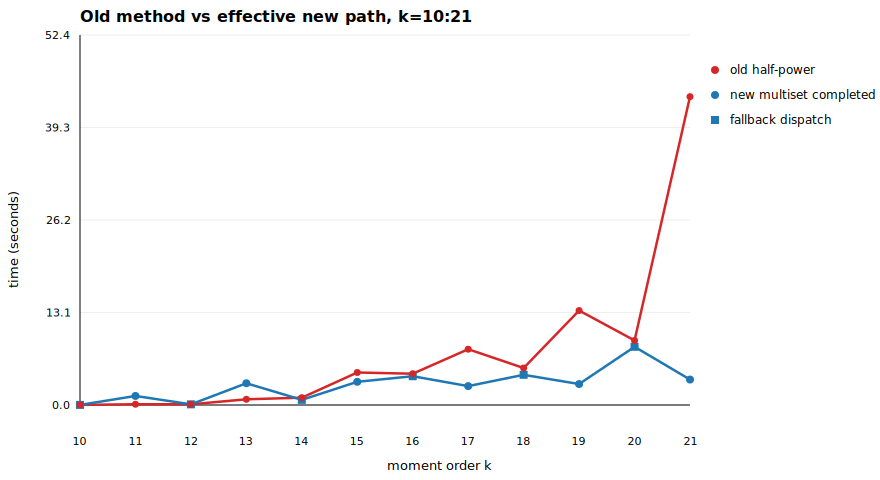

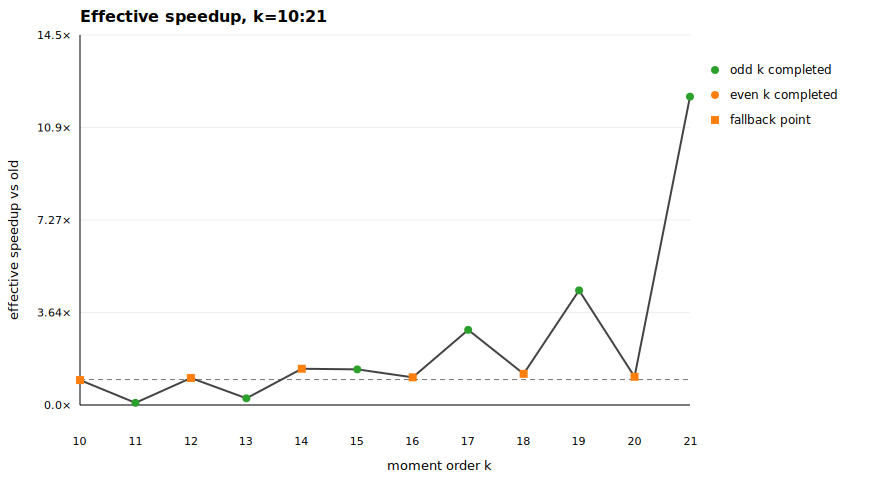

In [10]:
function mixed_cap_old_vs_new_svg(rows; width=880, height=480)
    isempty(rows) && return "<svg><text x='20' y='20'>No mixed-cap timing rows to plot.</text></svg>"

    left, right, top, bottom = 80.0, 190.0, 35.0, 75.0
    xs = Float64[r.k for r in rows]
    old_ys = Float64[r.old_time for r in rows]
    effective_new_ys = Float64[r.fallback ? r.public_time : r.new_total_time for r in rows]
    ymax = maximum(vcat(old_ys, effective_new_ys)) * 1.2
    ymax == 0 && (ymax = 1.0)
    xmin, xmax = minimum(xs), maximum(xs)
    xmax == xmin && (xmax += 1)

    xmap(x) = left + (x - xmin) / (xmax - xmin) * (width - left - right)
    ymap(y) = height - bottom - y / ymax * (height - top - bottom)

    function polyline(points, color)
        coords = join(["$(xmap(x)),$(ymap(y))" for (x, y) in points], " ")
        return "<polyline points='$coords' fill='none' stroke='$color' stroke-width='2.5'/>"
    end

    grid = String[]
    for frac in 0:0.25:1
        y = top + frac * (height - top - bottom)
        value = ymax * (1 - frac)
        push!(grid, "<line x1='$left' y1='$y' x2='$(width-right)' y2='$y' stroke='#eeeeee'/>")
        push!(grid, "<text x='$(left-10)' y='$(y+4)' text-anchor='end' font-size='11'>$(round(value, sigdigits=3))</text>")
    end

    xticks = join(["<text x='$(xmap(k))' y='$(height-35)' text-anchor='middle' font-size='11'>$(Int(k))</text>" for k in xs])
    old_line = polyline(zip(xs, old_ys), "#d62728")
    new_line = polyline(zip(xs, effective_new_ys), "#1f77b4")

    markers = String[]
    for r in rows
        new_y = r.fallback ? r.public_time : r.new_total_time
        shape = r.fallback ? "rect x='$(xmap(r.k)-4)' y='$(ymap(new_y)-4)' width='8' height='8'" : "circle cx='$(xmap(r.k))' cy='$(ymap(new_y))' r='4'"
        push!(markers, "<$shape fill='#1f77b4'><title>k=$(r.k), effective new=$(round(new_y, sigdigits=4))s, fallback=$(r.fallback)</title></$(r.fallback ? "rect" : "circle")>")
        push!(markers, "<circle cx='$(xmap(r.k))' cy='$(ymap(r.old_time))' r='3.5' fill='#d62728'><title>k=$(r.k), old=$(round(r.old_time, sigdigits=4))s</title></circle>")
    end

    return """
<svg width='$width' height='$height' viewBox='0 0 $width $height' xmlns='http://www.w3.org/2000/svg'>
  <rect width='100%' height='100%' fill='white'/>
  $(join(grid, "\n  "))
  <line x1='$left' y1='$(height-bottom)' x2='$(width-right)' y2='$(height-bottom)' stroke='black'/>
  <line x1='$left' y1='$top' x2='$left' y2='$(height-bottom)' stroke='black'/>
  $xticks
  $old_line
  $new_line
  $(join(markers, "\n  "))
  <text x='$(width/2)' y='$(height-10)' text-anchor='middle' font-size='13'>moment order k</text>
  <text transform='translate(18,$(height/2)) rotate(-90)' text-anchor='middle' font-size='13'>time (seconds)</text>
  <text x='$left' y='22' font-size='16' font-weight='bold'>Old method vs effective new path, k=10:21</text>
  <circle cx='$(width-right+25)' cy='70' r='4' fill='#d62728'/><text x='$(width-right+40)' y='74' font-size='12'>old half-power</text>
  <circle cx='$(width-right+25)' cy='95' r='4' fill='#1f77b4'/><text x='$(width-right+40)' y='99' font-size='12'>new multiset completed</text>
  <rect x='$(width-right+21)' y='116' width='8' height='8' fill='#1f77b4'/><text x='$(width-right+40)' y='124' font-size='12'>fallback dispatch</text>
</svg>
"""
end

function mixed_cap_speedup_svg(rows; width=880, height=480)
    isempty(rows) && return "<svg><text x='20' y='20'>No mixed-cap timing rows to plot.</text></svg>"

    left, right, top, bottom = 80.0, 190.0, 35.0, 75.0
    xs = Float64[r.k for r in rows]
    effective_speedups = Float64[r.old_time / (r.fallback ? r.public_time : r.new_total_time) for r in rows]
    ymax = maximum(effective_speedups) * 1.2
    ymax <= 1 && (ymax = 1.2)
    xmin, xmax = minimum(xs), maximum(xs)
    xmax == xmin && (xmax += 1)

    xmap(x) = left + (x - xmin) / (xmax - xmin) * (width - left - right)
    ymap(y) = height - bottom - y / ymax * (height - top - bottom)

    coords = join(["$(xmap(k)),$(ymap(s))" for (k, s) in zip(xs, effective_speedups)], " ")
    grid = String[]
    for frac in 0:0.25:1
        y = top + frac * (height - top - bottom)
        value = ymax * (1 - frac)
        push!(grid, "<line x1='$left' y1='$y' x2='$(width-right)' y2='$y' stroke='#eeeeee'/>")
        push!(grid, "<text x='$(left-10)' y='$(y+4)' text-anchor='end' font-size='11'>$(round(value, sigdigits=3))×</text>")
    end

    baseline_y = ymap(1.0)
    xticks = join(["<text x='$(xmap(k))' y='$(height-35)' text-anchor='middle' font-size='11'>$(Int(k))</text>" for k in xs])
    markers = String[]
    for (r, speedup) in zip(rows, effective_speedups)
        color = isodd(r.k) ? "#2ca02c" : "#ff7f0e"
        shape = r.fallback ? "rect x='$(xmap(r.k)-4)' y='$(ymap(speedup)-4)' width='8' height='8'" : "circle cx='$(xmap(r.k))' cy='$(ymap(speedup))' r='4'"
        push!(markers, "<$shape fill='$color'><title>k=$(r.k), effective speedup=$(round(speedup, sigdigits=4))×, fallback=$(r.fallback)</title></$(r.fallback ? "rect" : "circle")>")
    end

    return """
<svg width='$width' height='$height' viewBox='0 0 $width $height' xmlns='http://www.w3.org/2000/svg'>
  <rect width='100%' height='100%' fill='white'/>
  $(join(grid, "\n  "))
  <line x1='$left' y1='$baseline_y' x2='$(width-right)' y2='$baseline_y' stroke='#777777' stroke-dasharray='5 4'/>
  <line x1='$left' y1='$(height-bottom)' x2='$(width-right)' y2='$(height-bottom)' stroke='black'/>
  <line x1='$left' y1='$top' x2='$left' y2='$(height-bottom)' stroke='black'/>
  $xticks
  <polyline points='$coords' fill='none' stroke='#444444' stroke-width='2'/>
  $(join(markers, "\n  "))
  <text x='$(width/2)' y='$(height-10)' text-anchor='middle' font-size='13'>moment order k</text>
  <text transform='translate(18,$(height/2)) rotate(-90)' text-anchor='middle' font-size='13'>effective speedup vs old</text>
  <text x='$left' y='22' font-size='16' font-weight='bold'>Effective speedup, k=10:21</text>
  <circle cx='$(width-right+25)' cy='70' r='4' fill='#2ca02c'/><text x='$(width-right+40)' y='74' font-size='12'>odd k completed</text>
  <circle cx='$(width-right+25)' cy='95' r='4' fill='#ff7f0e'/><text x='$(width-right+40)' y='99' font-size='12'>even k completed</text>
  <rect x='$(width-right+21)' y='116' width='8' height='8' fill='#ff7f0e'/><text x='$(width-right+40)' y='124' font-size='12'>fallback point</text>
</svg>
"""
end

old_vs_new_svg = mixed_cap_old_vs_new_svg(mixed_cap_timing)
speedup_svg = mixed_cap_speedup_svg(mixed_cap_timing)

display("image/svg+xml", old_vs_new_svg)
display("image/svg+xml", speedup_svg)


## 8. Odd high-order probe up to $k=41$

The detailed timing table above already compares the requested odd orders.  Because full moment benchmarks for every odd $k>10$ can be very expensive, this supplementary probe checks the identity-parity stage for the same odd orders

$$
k \in \{11,13,15,\ldots,41\}.
$$

This tells us which odd orders can even pass the first issue-#80 pruning step under a chosen cap.  Rows marked `fallback cap` exceeded the cap before a full multiset timing would be meaningful.  Use this to understand which detailed-timing rows fell back because the parity stage alone exceeded the cap.


In [ ]:
function odd_k_parity_cap_probe(H; k_values=11:2:41, caps=(200_000, 2_000_000))
    strings = H.strings
    rows = NamedTuple[]
    @printf("%10s %3s %12s %12s %13s\n", "cap", "k", "parity_time", "patterns", "note")
    for cap in caps
        for k in k_values
            parity_time = @elapsed patterns = notebook_identity_parity_patterns(strings, k; maxstates=cap)
            fallback = isnothing(patterns)
            pattern_count = fallback ? 0 : length(patterns)
            note = fallback ? "fallback cap" : "parity ok"
            push!(rows, (; cap, k, parity_time, pattern_count, fallback, note))
            @printf("%10d %3d %12.4g %12d %13s\n", cap, k, parity_time, pattern_count, note)
        end
    end
    return rows
end

odd_k_probe = odd_k_parity_cap_probe(H_demo; k_values=11:2:41, caps=(200_000, 2_000_000))

# Example follow-up after inspecting odd_k_probe:
# promising_ks = [r.k for r in odd_k_probe if !r.fallback && r.cap == 2_000_000]
# full_odd_timing = benchmark_with_multiset_caps(H_demo; k_values=promising_ks, caps=(2_000_000, 5_000_000), samples=1)


       cap   k  parity_time     patterns          note
    200000  11      0.01348            0  fallback cap
    200000  13        0.013            0  fallback cap
    200000  15      0.01308            0  fallback cap
    200000  17       0.0135            0  fallback cap
    200000  19      0.01283            0  fallback cap
    200000  21      0.01368            0  fallback cap
    200000  23      0.01289            0  fallback cap
    200000  25      0.01414            0  fallback cap
    200000  27      0.01329            0  fallback cap
    200000  29      0.01303            0  fallback cap
    200000  31      0.01298            0  fallback cap
    200000  33      0.01306            0  fallback cap
    200000  35      0.01297            0  fallback cap
    200000  37      0.01313            0  fallback cap
    200000  39      0.01508            0  fallback cap
    200000  41      0.01325            0  fallback cap
   2000000  11       0.1243            0  fallback cap
   2000000

32-element Vector{NamedTuple}:
 (cap = 200000, k = 11, parity_time = 0.013478938, pattern_count = 0, fallback = true, note = "fallback cap")
 (cap = 200000, k = 13, parity_time = 0.013002971, pattern_count = 0, fallback = true, note = "fallback cap")
 (cap = 200000, k = 15, parity_time = 0.013077785, pattern_count = 0, fallback = true, note = "fallback cap")
 (cap = 200000, k = 17, parity_time = 0.013497202, pattern_count = 0, fallback = true, note = "fallback cap")
 (cap = 200000, k = 19, parity_time = 0.012832551, pattern_count = 0, fallback = true, note = "fallback cap")
 (cap = 200000, k = 21, parity_time = 0.013679092, pattern_count = 0, fallback = true, note = "fallback cap")
 (cap = 200000, k = 23, parity_time = 0.012894091, pattern_count = 0, fallback = true, note = "fallback cap")
 (cap = 200000, k = 25, parity_time = 0.014135359, pattern_count = 0, fallback = true, note = "fallback cap")
 (cap = 200000, k = 27, parity_time = 0.013289869, pattern_count = 0, fallback = true, no

## Final note: Interpretation

The main speedup comes from removing redundant orderings.  The ordered expansion sees

$$
M^k
$$

products, while multiset grouping sees at most

$$
\binom{M+k-1}{k}
$$

candidate count vectors.  For $M\gg k$, the ratio is approximately $k!$.

The parity-pruned implementation goes further by requiring

$$
\bigoplus_{i:n_i\text{ odd}} P_i = I,
$$

then distributing only the remaining pairs

$$
q = \frac{k-|S|}{2}.
$$

The timing decomposition above is meant to show which part dominates for the chosen Hamiltonian: odd-support enumeration, pair distribution, or phase summation.  `public_time` is not the baseline for the speedup ratio; it is a dispatch sanity check and is expected to track `old_time` whenever the public implementation chooses the fallback.

If the plotted speedup is below $1$, the benchmark point is still in the constant-overhead regime: parity-pattern sets, pair enumeration, per-multiset phase memoization, and instrumentation overhead cost more than the old half-power method saves.  If the table shows `NaN`, the multiset instrumentation did not finish: it hit `NOTEBOOK_MULTISET_MAX_REACHABLE`, marked the row as `fallback`, and therefore has no valid completed multiset runtime for the ratio.  